In [ ]:
from common.loading_real_wave_noise import loading_real_wave_noise
from common.Reading_path_test import loading_paths_from_MAT
from data.Disturbance_generation import Disturbance_generation_from_real_noise
import torchaudio
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
from scipy import signal

In [47]:
folder = "Pz and Sz"
subfolder = "Secondary_path_delay_50samples"
# subfolder = "Dongyuan"
Pri_path_file_name = "Primary_path.mat"
Sec_path_file_name = "Secondary_path.mat"
pri_path, sec_path = loading_paths_from_MAT(folder, subfolder, Pri_path_file_name, Sec_path_file_name)
sound_name = "1_Frequency_from_1400_to_1900_10s_Hz"
waveform, fs = loading_real_wave_noise(folde_name="Real Noise Examples/syn", sound_name=sound_name+".wav")
# waveform = waveform.squeeze()
repeat = 0
dis, ref, _ = Disturbance_generation_from_real_noise(fs, repeat, wave_form=waveform, Pri_path=pri_path, Sec_path=sec_path)

In [48]:
sec_path.shape

(434,)

In [2]:
import torch
import torch.nn.functional as F
import scipy.io as sio
from pathlib import Path
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
dtype = torch.float32
path_folder = Path.cwd() / "Pz and Sz" / "Dongyuan"
pri_path, sec_path = torch.tensor(sio.loadmat(path_folder/"Primary_path.mat")["Pz1"], device=device, dtype=dtype).squeeze(1), torch.tensor(sio.loadmat(path_folder/"Secondary_path.mat")["S"], device=device, dtype=dtype).squeeze(1)

In [3]:
def fir_filter(signal, path):
    signal = signal.view(1, 1, -1)
    path = path.flip(0).view(1, 1, -1)
    y = F.conv1d(signal, path, padding=path.shape[-1] - 1)
    return y[0, 0, :len(signal.flatten())]

In [4]:
noise_len = 160000
num_taps = 1024 * 2
delay=5
noise = 2 * torch.rand(noise_len, device=device, dtype=dtype) - 1
sec_path = torch.cat([torch.zeros(pri_path.argmax()-sec_path.argmax() +delay, device=device, dtype=dtype), sec_path])
d = fir_filter(noise, pri_path)
xf = fir_filter(noise, sec_path)


In [ ]:
from scipy import signal
import scipy.io as sio
import numpy as np
from pathlib import Path
from fxlms.FxLMS_algorithm_v2 import train_fast_lms_algorithm, SuperFastFxLMS
fs, seconds, numtaps, hz = 16000, 1, 1024, 1000
for i in range(10):
    delay=10 * i
    path_folder = Path.cwd() / "Pz and Sz" / "Dongyuan"
    noise = np.sin(2 * np.pi * hz* np.linspace(0, seconds, fs))
    pri_path, sec_path = sio.loadmat(path_folder/"Primary_path.mat")["Pz1"].squeeze(), sio.loadmat(path_folder/"Secondary_path.mat")["S"].squeeze()
    sec_path = np.concat([np.zeros(np.abs(pri_path).argmax()-np.abs(sec_path).argmax() +delay), sec_path])
    dis = signal.lfilter(pri_path, 1, noise)
    fx = signal.lfilter(sec_path, 1, noise)
    model = SuperFastFxLMS(numtaps, sec_path=sec_path)
    e = train_fast_lms_algorithm(model, noise, dis, 0.01)

    print(10 * np.log10(np.mean(np.square(e))/np.mean(np.square(dis))))

-13.713556054447247
-11.68722855637574
-11.282951019193089
-1.9474902488036818
-7.097072473402979
-0.5438523216310083
9.551913521047041
20.13734706877175
28.325084230143858
40.13047311045986


In [ ]:
from fxlms.FxLMS_algorithm_v2 import train_fast_lms_algorithm, SuperFastNLMS
ref = xf.cpu().numpy()
dis = d.cpu().numpy()
model = SuperFastNLMS(1024)
error = train_fast_lms_algorithm(model, ref, dis, 0.05)
import numpy as np
10 * np.log10(np.mean(np.array(error)) / np.mean(np.array(dis)))

ValueError: Device not understood. Only "cpu" is allowed, but received: cuda:0

In [12]:
sound_names = [name[:-len(".wav")] for name in os.listdir(folder_name)]
print(sound_names)

['B_Ⅰ_1_20251029', 'B_Ⅲ_2_20251029', 'B_Ⅰ_3_20251029', 'A_Ⅱ_1_20250917', 'B_Ⅱ_1_20251029', 'B_Ⅳ_2_20251029', 'A_Ⅲ_2_20250917', 'A_Ⅱ_3_20250917', 'B_Ⅱ_3_20251029', 'A_Ⅲ_1_20250917', 'B_Ⅰ_2_20251029', 'A_Ⅰ_3_20250917', 'A_Ⅳ_3_20250917', 'A_Ⅰ_2_20250917', 'B_Ⅳ_1_20251029', 'A_Ⅱ_2_20250917', 'B_Ⅲ_3_20251029', 'A_Ⅰ_1_20250917', 'A_Ⅳ_1_20250917', 'B_Ⅲ_1_20251029', 'A_Ⅲ_3_20250917', 'B_Ⅳ_3_20251029', 'A_Ⅳ_2_20250917', 'B_Ⅱ_2_20251029']


In [4]:
folder_name = "20250506_音データ"
sound_names = [name[:-len(".wav")] for name in os.listdir(folder_name)]
for sound_name in sound_names:
    # sound_name = "A_Ⅰ_1_20250917"
    waveform, fs = loading_real_wave_noise(folder_name, sound_name=sound_name+".wav")
    waveform = waveform[0,:]
    # waveform = torch.mean(waveform, dim=0)
    print(waveform.shape)
    # waveform = waveform.squeeze()
    # repeat = 0
    # dis, ref, _ = Disturbance_generation_from_real_noise(fs, repeat, wave_form=waveform, Pri_path=pri_path, Sec_path=sec_path)from scipy import signal
    wave = waveform
    fs = fs
    savefolder = "dft"
    f, Pxx_den = signal.welch(wave.squeeze().numpy(), fs, scaling="spectrum")
    Pxx_dB = 10 * np.log10(Pxx_den / np.max(Pxx_den))

    plt.figure(figsize=(6, 4))
    plt.plot(f, Pxx_dB, color="blue")
    plt.title("Power Spectrum (Welch's Method)")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Normalized Power [dB]")
    plt.xlim(0, 8000)
    plt.ylim(-80, 5)  # -80 dB 程度までを表示範囲にすると見やすくなります
    plt.grid(True)
    plt.savefig(os.path.join(savefolder, sound_name+"_dft"+".png"))
    plt.close()

torch.Size([320001])
torch.Size([160001])
torch.Size([320001])
torch.Size([288001])
torch.Size([288001])
torch.Size([160001])
torch.Size([160001])
torch.Size([288001])
torch.Size([288001])
torch.Size([160001])
torch.Size([320001])
torch.Size([320001])
torch.Size([160001])
torch.Size([320001])
torch.Size([160001])
torch.Size([288001])
torch.Size([160001])
torch.Size([320001])
torch.Size([160001])
torch.Size([160001])
torch.Size([160001])
torch.Size([160001])
torch.Size([160001])
torch.Size([288001])


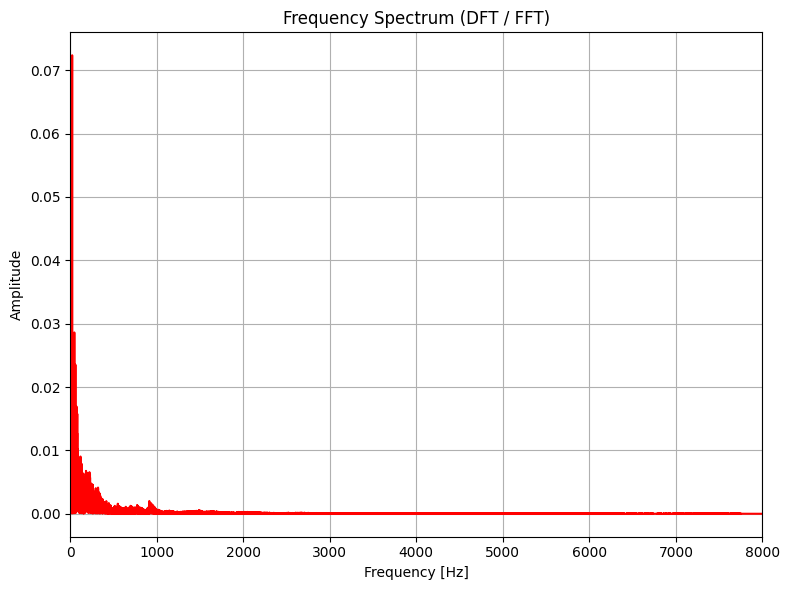

In [19]:
N = waveform.shape[0]
t = np.arange(N) / fs
fft_vals = np.fft.fft(waveform.numpy())

freq = np.fft.fftfreq(N,1/fs)
half_N = N // 2

pos_freqs = freq[:half_N]
amplitude = np.abs(fft_vals[:half_N]) / N
amplitude[1:] = amplitude[1:] * 2

fig, ax2 = plt.subplots(1, 1, figsize=(8, 6))

# (2) 周波数スペクトルのプロット
ax2.plot(pos_freqs, amplitude, color='red')
ax2.set_title("Frequency Spectrum (DFT / FFT)")
ax2.set_xlabel("Frequency [Hz]")
ax2.set_ylabel("Amplitude")
ax2.set_xlim(0, fs//2) # 200Hzまでの領域を表示
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from fxlms.FxLMS_algorithm_v2 import SuperFastLMS, train_fast_lms_algorithm
model = SuperFastLMS(Len=1024)
Stepsize = 1 * 0.1 ** 2
error = train_fast_lms_algorithm(model, ref, dis, Stepsize)

In [23]:
Time = np.arange(len(dis)) / (1/fs)

In [24]:
import numpy as np
10*np.log10(np.mean(np.square(np.array(error))) / np.mean(np.square(dis.numpy())))

np.float64(-15.653465622192975)

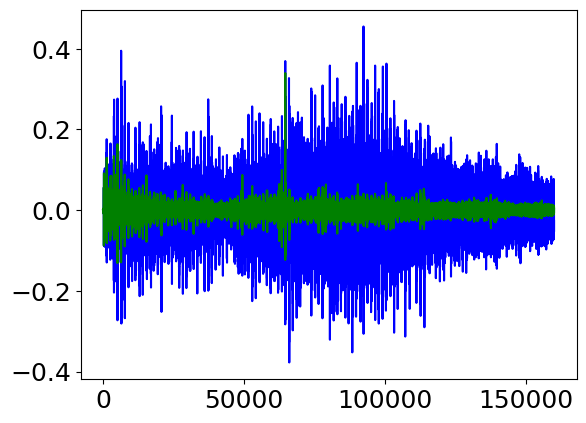

In [25]:
import matplotlib.pyplot as plt
plt.plot(dis.numpy(), color="blue")
plt.plot(error, color="green")


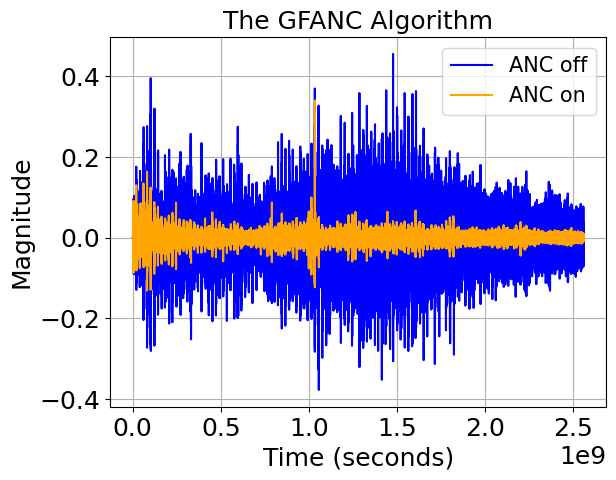

In [26]:
plt.rc('axes', titlesize=18) # fontsize of the axes title
plt.rc('axes', labelsize=18) # fontsize of the x and y labels
plt.rc('xtick', labelsize=18) # fontsize of the tick labels
plt.rc('ytick', labelsize=18) # fontsize of the tick labels
plt.rc('legend', fontsize=15) # legend fontsize
plt.rc('figure', titlesize=18) # fontsize of the figure title

plt.title('The GFANC Algorithm')
plt.plot(Time, dis, color='blue', label='ANC off')
plt.plot(Time, error, color='orange', label='ANC on')
plt.ylabel('Magnitude')
plt.xlabel('Time (seconds)')
plt.legend()
plt.grid()

plt.show()